# Chapter 7: Multifactor Models and Performance Measures

This atlas follows the lecture sequence and uses deterministic financial data so
that every code module can run without an internet connection.

## Learning map

1. Fama-French three-factor regression
2. Carhart four-factor and Fama-French five-factor models
3. R-squared, adjusted R-squared, and the F-test
4. Sharpe, Treynor, Sortino, and Jensen alpha
5. Preparing factor data and date indices

**Code availability:** Yes. Every code cell imports its own dependencies,
contains Chinese exam-oriented comments, and produces an interpretable result.

## How to Study This Chapter

- **First pass:** Read the concept and formula sections without running code.
- **Second pass:** Predict the output and fill in the commented key lines before execution.
- **Third pass:** Run each module independently and explain the result in one sentence.
- **Final review:** Compare related methods and identify when each method should or should not be used.

## Chapter Checklist

- Can I define every variable and state its unit?
- Can I reproduce the main formula or workflow without looking?
- Can I identify the code lines most likely to appear as blanks?
- Can I interpret the output economically or statistically?
- Can I name at least one common implementation error?


## 7.1 Fama-French Three-Factor Model

The model explains excess return using market, size (SMB), and value (HML) factors.


### Structured Review

- **Return basis:** Use excess return when the model or performance measure requires subtraction of the risk-free rate.
- **Risk denominator:** Match total risk, beta, or downside deviation to the correct measure.
- **Factor exposure:** Interpret each slope as sensitivity to a named systematic factor.
- **Model comparison:** Prefer adjusted R-squared when models contain different numbers of factors.

### Measure Map

| Measure | Numerator | Denominator |
|---|---|---|
| Sharpe | Mean excess return | Total standard deviation |
| Treynor | Mean excess return | Beta |
| Sortino | Mean excess return | Downside deviation |
| Jensen alpha | Realized minus CAPM-predicted return | None |

### Exam Focus

- Identify the correct denominator from the measure name.
- Keep factor returns and asset returns in the same units and frequency.
- State the null hypothesis for an individual t-test and the overall F-test.

### Common Mistakes

- Using total return instead of excess return in a factor regression.
- Comparing raw R-squared across models with different factor counts.
- Minimizing the positive Sharpe ratio instead of minimizing its negative.


In [1]:
'''
本单元使用矩阵公式估计多元线性回归，避免依赖特定回归软件。
X 第一列加入常数 1，对应回归截距 alpha。
'''
import numpy as np

rng = np.random.default_rng(300 + 3)
n = 360
factor_names = ['Market', 'SMB', 'HML']
factors = rng.normal(0, 0.01, (n, len(factor_names)))
true_betas = np.linspace(1.10, 0.25, len(factor_names))
asset_excess_return = 0.0002 + factors @ true_betas + rng.normal(0, 0.008, n)

# np.column_stack 加入常数列，形成 [1, factor1, factor2, ...]
X = np.column_stack([np.ones(n), factors])

# 最小二乘解 beta_hat = (X'X)^(-1)X'y；lstsq 数值更稳定
coefficients = np.linalg.lstsq(X, asset_excess_return, rcond=None)[0]
fitted = X @ coefficients
residuals = asset_excess_return - fitted

# R-squared = 1 - SSE/SST
r_squared = 1 - np.sum(residuals**2) / np.sum((asset_excess_return - asset_excess_return.mean())**2)

# 调整 R-squared 对因子数量进行惩罚
p = len(factor_names)
adjusted_r_squared = 1 - (1 - r_squared) * (n - 1) / (n - p - 1)

print("Factor names =", factor_names)
print("Estimated [alpha, betas] =", np.round(coefficients, 4))
print("R-squared =", round(float(r_squared), 4))
print("Adjusted R-squared =", round(float(adjusted_r_squared), 4))


Factor names = ['Market', 'SMB', 'HML']
Estimated [alpha, betas] = [0.     1.1014 0.7235 0.2449]
R-squared = 0.7463
Adjusted R-squared = 0.7441


**Result interpretation.** The coefficients are factor exposures; adjusted R-squared is preferable when comparing models with different factor counts.

### Result Checklist

- Confirm that the sign and magnitude are economically reasonable.
- Match the output to the formula, decision rule, or statistical hypothesis described above.
- If the result differs from expectation, inspect input frequency, indexing, and parameter order first.


## 7.2 Four- and Five-Factor Models

Carhart adds momentum (MOM). The five-factor model adds profitability (RMW) and investment (CMA).


### Structured Review

- **Return basis:** Use excess return when the model or performance measure requires subtraction of the risk-free rate.
- **Risk denominator:** Match total risk, beta, or downside deviation to the correct measure.
- **Factor exposure:** Interpret each slope as sensitivity to a named systematic factor.
- **Model comparison:** Prefer adjusted R-squared when models contain different numbers of factors.

### Measure Map

| Measure | Numerator | Denominator |
|---|---|---|
| Sharpe | Mean excess return | Total standard deviation |
| Treynor | Mean excess return | Beta |
| Sortino | Mean excess return | Downside deviation |
| Jensen alpha | Realized minus CAPM-predicted return | None |

### Exam Focus

- Identify the correct denominator from the measure name.
- Keep factor returns and asset returns in the same units and frequency.
- State the null hypothesis for an individual t-test and the overall F-test.

### Common Mistakes

- Using total return instead of excess return in a factor regression.
- Comparing raw R-squared across models with different factor counts.
- Minimizing the positive Sharpe ratio instead of minimizing its negative.


In [2]:
'''
本单元使用矩阵公式估计多元线性回归，避免依赖特定回归软件。
X 第一列加入常数 1，对应回归截距 alpha。
'''
import numpy as np

rng = np.random.default_rng(300 + 6)
n = 360
factor_names = ['Market', 'SMB', 'HML', 'MOM', 'RMW', 'CMA']
factors = rng.normal(0, 0.01, (n, len(factor_names)))
true_betas = np.linspace(1.10, 0.25, len(factor_names))
asset_excess_return = 0.0002 + factors @ true_betas + rng.normal(0, 0.008, n)

# np.column_stack 加入常数列，形成 [1, factor1, factor2, ...]
X = np.column_stack([np.ones(n), factors])

# 最小二乘解 beta_hat = (X'X)^(-1)X'y；lstsq 数值更稳定
coefficients = np.linalg.lstsq(X, asset_excess_return, rcond=None)[0]
fitted = X @ coefficients
residuals = asset_excess_return - fitted

# R-squared = 1 - SSE/SST
r_squared = 1 - np.sum(residuals**2) / np.sum((asset_excess_return - asset_excess_return.mean())**2)

# 调整 R-squared 对因子数量进行惩罚
p = len(factor_names)
adjusted_r_squared = 1 - (1 - r_squared) * (n - 1) / (n - p - 1)

print("Factor names =", factor_names)
print("Estimated [alpha, betas] =", np.round(coefficients, 4))
print("R-squared =", round(float(r_squared), 4))
print("Adjusted R-squared =", round(float(adjusted_r_squared), 4))


Factor names = ['Market', 'SMB', 'HML', 'MOM', 'RMW', 'CMA']
Estimated [alpha, betas] = [-1.0000e-04  1.1269e+00  8.8700e-01  7.4120e-01  5.3500e-01  3.9160e-01
  2.5480e-01]
R-squared = 0.8213
Adjusted R-squared = 0.8183


**Result interpretation.** The expanded model estimates six factor exposures. Extra factors should be retained only when they add explanatory value.

### Result Checklist

- Confirm that the sign and magnitude are economically reasonable.
- Match the output to the formula, decision rule, or statistical hypothesis described above.
- If the result differs from expectation, inspect input frequency, indexing, and parameter order first.

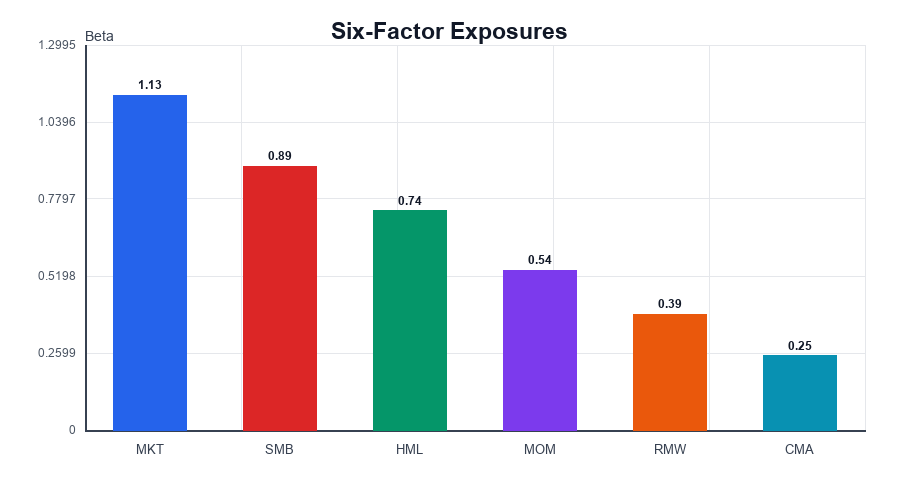


## 7.3 Overall F-Test for a Factor Model

The overall F-test evaluates whether all slope coefficients are jointly zero. A small p-value means at least one factor contributes explanatory power.


### Structured Review

- **Return basis:** Use excess return when the model or performance measure requires subtraction of the risk-free rate.
- **Risk denominator:** Match total risk, beta, or downside deviation to the correct measure.
- **Factor exposure:** Interpret each slope as sensitivity to a named systematic factor.
- **Model comparison:** Prefer adjusted R-squared when models contain different numbers of factors.

### Measure Map

| Measure | Numerator | Denominator |
|---|---|---|
| Sharpe | Mean excess return | Total standard deviation |
| Treynor | Mean excess return | Beta |
| Sortino | Mean excess return | Downside deviation |
| Jensen alpha | Realized minus CAPM-predicted return | None |

### Exam Focus

- Identify the correct denominator from the measure name.
- Keep factor returns and asset returns in the same units and frequency.
- State the null hypothesis for an individual t-test and the overall F-test.

### Common Mistakes

- Using total return instead of excess return in a factor regression.
- Comparing raw R-squared across models with different factor counts.
- Minimizing the positive Sharpe ratio instead of minimizing its negative.


In [3]:
'''
本单元从 R-squared 构造整体 F 统计量。
k 是斜率因子数，不包括常数项；n-k-1 是残差自由度。
'''
from scipy import stats

n = 477
k = 3
r_squared = 0.022
alpha = 0.05

# F = (R2/k) / ((1-R2)/(n-k-1))
f_value = (r_squared / k) / ((1 - r_squared) / (n - k - 1))

# F 检验位于右尾，因此使用 1-CDF 计算 p 值
p_value = 1 - stats.f.cdf(f_value, k, n - k - 1)
critical_value = stats.f.ppf(1 - alpha, k, n - k - 1)

print("F-value =", round(float(f_value), 4))
print("Critical F =", round(float(critical_value), 4))
print("p-value =", round(float(p_value), 6))
print("Decision =", "Reject H0" if p_value < alpha else "Do not reject H0")


F-value = 3.5467
Critical F = 2.6238
p-value = 0.014537
Decision = Reject H0


**Result interpretation.** The test concerns all factor slopes jointly, unlike individual t-tests.

### Result Checklist

- Confirm that the sign and magnitude are economically reasonable.
- Match the output to the formula, decision rule, or statistical hypothesis described above.
- If the result differs from expectation, inspect input frequency, indexing, and parameter order first.


## 7.4 Risk-Adjusted Performance Measures


Sharpe uses total risk; Treynor uses beta; Sortino uses downside risk. Jensen
alpha is realized excess return minus CAPM-predicted excess return.



### Structured Review

- **Return basis:** Use excess return when the model or performance measure requires subtraction of the risk-free rate.
- **Risk denominator:** Match total risk, beta, or downside deviation to the correct measure.
- **Factor exposure:** Interpret each slope as sensitivity to a named systematic factor.
- **Model comparison:** Prefer adjusted R-squared when models contain different numbers of factors.

### Measure Map

| Measure | Numerator | Denominator |
|---|---|---|
| Sharpe | Mean excess return | Total standard deviation |
| Treynor | Mean excess return | Beta |
| Sortino | Mean excess return | Downside deviation |
| Jensen alpha | Realized minus CAPM-predicted return | None |

### Exam Focus

- Identify the correct denominator from the measure name.
- Keep factor returns and asset returns in the same units and frequency.
- State the null hypothesis for an individual t-test and the overall F-test.

### Common Mistakes

- Using total return instead of excess return in a factor regression.
- Comparing raw R-squared across models with different factor counts.
- Minimizing the positive Sharpe ratio instead of minimizing its negative.


In [4]:
'''
本单元计算四种常用绩效指标。
所有收益率和无风险利率必须使用相同频率。
'''
import numpy as np

returns = np.array([0.04, -0.02, 0.03, 0.01, -0.01, 0.05, 0.02])
risk_free = 0.005
market_mean = 0.018
beta = 1.20

mean_return = returns.mean()
total_risk = returns.std(ddof=1)

# Sharpe = 平均超额收益 / 总标准差
sharpe = (mean_return - risk_free) / total_risk

# Treynor = 平均超额收益 / beta
treynor = (mean_return - risk_free) / beta

# 下行收益只保留低于基准 risk_free 的观测
downside = returns[returns < risk_free]
downside_deviation = np.sqrt(np.mean((downside - risk_free) ** 2))
sortino = (mean_return - risk_free) / downside_deviation

# Jensen alpha = 实际超额收益 - beta × 市场超额收益
jensen_alpha = (mean_return - risk_free) - beta * (market_mean - risk_free)

print("Sharpe =", round(float(sharpe), 4))
print("Treynor =", round(float(treynor), 4))
print("Sortino =", round(float(sortino), 4))
print("Jensen alpha =", round(float(jensen_alpha), 4))


Sharpe = 0.4737
Treynor = 0.0101
Sortino = 0.589
Jensen alpha = -0.0035


**Result interpretation.** Different measures answer different risk questions, so their denominators should not be interchanged.

### Result Checklist

- Confirm that the sign and magnitude are economically reasonable.
- Match the output to the formula, decision rule, or statistical hypothesis described above.
- If the result differs from expectation, inspect input frequency, indexing, and parameter order first.

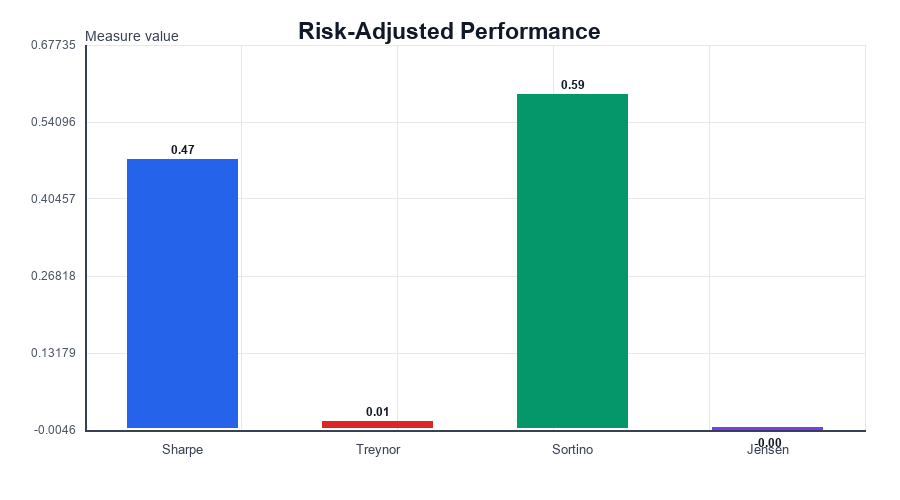


## 7.5 Preparing Fama-French Dates and Percentages

Academic factor files often encode dates as integers and returns as percentages. Before merging, convert both date and units consistently.


### Structured Review

- **Return basis:** Use excess return when the model or performance measure requires subtraction of the risk-free rate.
- **Risk denominator:** Match total risk, beta, or downside deviation to the correct measure.
- **Factor exposure:** Interpret each slope as sensitivity to a named systematic factor.
- **Model comparison:** Prefer adjusted R-squared when models contain different numbers of factors.

### Measure Map

| Measure | Numerator | Denominator |
|---|---|---|
| Sharpe | Mean excess return | Total standard deviation |
| Treynor | Mean excess return | Beta |
| Sortino | Mean excess return | Downside deviation |
| Jensen alpha | Realized minus CAPM-predicted return | None |

### Exam Focus

- Identify the correct denominator from the measure name.
- Keep factor returns and asset returns in the same units and frequency.
- State the null hypothesis for an individual t-test and the overall F-test.

### Common Mistakes

- Using total return instead of excess return in a factor regression.
- Comparing raw R-squared across models with different factor counts.
- Minimizing the positive Sharpe ratio instead of minimizing its negative.


In [5]:
'''
本单元把 YYYYMMDD 整数日期转换为 datetime，并把百分数转换为小数。
这是合并 Fama-French 数据前最容易出现填空错误的步骤。
'''
from datetime import datetime

raw_rows = [
    (20260102, 0.35, -0.12, 0.08, 0.01),
    (20260105, -0.20, 0.05, -0.03, 0.01),
]

processed = []
for raw_date, market_rf, smb, hml, rf in raw_rows:
    # strptime 的格式 %Y%m%d 对应 8 位整数日期
    date = datetime.strptime(str(raw_date), "%Y%m%d").date()

    # 因子文件通常以百分数表示，除以 100 转换为小数收益率
    factors = tuple(value / 100 for value in (market_rf, smb, hml, rf))
    processed.append((date, *factors))

print("Processed factor rows =")
for row in processed:
    print(row)


Processed factor rows =
(datetime.date(2026, 1, 2), 0.0034999999999999996, -0.0012, 0.0008, 0.0001)
(datetime.date(2026, 1, 5), -0.002, 0.0005, -0.0003, 0.0001)


**Result interpretation.** The processed rows are ready for date-indexed merging with asset returns.

### Result Checklist

- Confirm that the sign and magnitude are economically reasonable.
- Match the output to the formula, decision rule, or statistical hypothesis described above.
- If the result differs from expectation, inspect input frequency, indexing, and parameter order first.


## 7.6 Lower Partial Standard Deviation


LPSD measures only returns below a benchmark. It is the downside-risk
denominator used by the Sortino ratio and appears explicitly in the classroom
source code.



### Structured Review

- **Purpose:** State what the code calculates and why the quantity matters in finance.
- **Inputs:** Identify the required data, parameter units, and expected data type.
- **Process:** Follow the transformation in execution order rather than reading only the final line.
- **Output:** Connect the printed value to an economic or statistical interpretation.

### Exam Focus

- Identify the lines most likely to be removed in a code-completion question.
- Trace dimensions, indices, and units through each intermediate variable.
- Use a small numerical example to check the direction and scale of the answer.

### Common Mistakes

- Reusing a variable with a different meaning.
- Depending on a previous notebook cell for an import or intermediate object.
- Reporting a number without explaining its financial meaning.


In [6]:
'''
本单元封装下行标准差 LPSD。
先筛选低于基准的收益率，再计算相对基准的平方偏差。
'''
import numpy as np

def lower_partial_standard_deviation(returns, benchmark):
    returns = np.asarray(returns, dtype=float)

    # 布尔筛选只保留低于 benchmark 的下行观测
    downside_returns = returns[returns < benchmark]
    if len(downside_returns) < 2:
        return 0.0

    # LPSD 使用下行偏差的样本均方根
    variance = np.sum((downside_returns - benchmark) ** 2) / (len(downside_returns) - 1)
    return np.sqrt(variance)

returns = np.array([0.04, -0.02, 0.03, -0.01, 0.01, -0.04, 0.05])
benchmark = 0.005
lpsd = lower_partial_standard_deviation(returns, benchmark)
sortino = (returns.mean() - benchmark) / lpsd

print("LPSD =", round(float(lpsd), 5))
print("Sortino ratio =", round(float(sortino), 5))


LPSD = 0.03791
Sortino ratio = 0.0942


**Result interpretation.** Only observations below the benchmark enter LPSD, unlike standard deviation, which treats upside and downside variation symmetrically.

### Result Checklist

- Confirm that the sign and magnitude are economically reasonable.
- Match the output to the formula, decision rule, or statistical hypothesis described above.
- If the result differs from expectation, inspect input frequency, indexing, and parameter order first.


## 7.7 Classroom Extension: Maximizing a Portfolio Sharpe Ratio


The source script extends performance measurement to multiple assets and uses
optimization. Because portfolio weights sum to one, only `n-1` weights are
independent; the final weight can be inferred.



### Structured Review

- **Return basis:** Use excess return when the model or performance measure requires subtraction of the risk-free rate.
- **Risk denominator:** Match total risk, beta, or downside deviation to the correct measure.
- **Factor exposure:** Interpret each slope as sensitivity to a named systematic factor.
- **Model comparison:** Prefer adjusted R-squared when models contain different numbers of factors.

### Measure Map

| Measure | Numerator | Denominator |
|---|---|---|
| Sharpe | Mean excess return | Total standard deviation |
| Treynor | Mean excess return | Beta |
| Sortino | Mean excess return | Downside deviation |
| Jensen alpha | Realized minus CAPM-predicted return | None |

### Exam Focus

- Identify the correct denominator from the measure name.
- Keep factor returns and asset returns in the same units and frequency.
- State the null hypothesis for an individual t-test and the overall F-test.

### Common Mistakes

- Using total return instead of excess return in a factor regression.
- Comparing raw R-squared across models with different factor counts.
- Minimizing the positive Sharpe ratio instead of minimizing its negative.


In [7]:
'''
本单元补充源代码中的多资产 Sharpe Ratio 优化。
优化器执行最小化，因此目标函数返回负的 Sharpe Ratio。
'''
import numpy as np
from scipy.optimize import minimize

expected_returns = np.array([0.08, 0.11, 0.06])
covariance = np.array([
    [0.040, 0.012, 0.008],
    [0.012, 0.062, 0.010],
    [0.008, 0.010, 0.025],
])
risk_free = 0.02

def portfolio_sharpe(weights):
    portfolio_return = weights @ expected_returns
    # 组合方差的矩阵公式为 w'Σw
    portfolio_variance = weights @ covariance @ weights
    return (portfolio_return - risk_free) / np.sqrt(portfolio_variance)

def negative_sharpe(weights):
    # minimize 负 Sharpe 等价于 maximize Sharpe
    return -portfolio_sharpe(weights)

constraints = {"type": "eq", "fun": lambda weights: weights.sum() - 1}
bounds = [(0, 1)] * len(expected_returns)
initial_weights = np.ones(len(expected_returns)) / len(expected_returns)

result = minimize(
    negative_sharpe,
    initial_weights,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints,
)

print("Optimal weights =", np.round(result.x, 4))
print("Weight sum =", round(float(result.x.sum()), 6))
print("Optimal Sharpe =", round(float(portfolio_sharpe(result.x)), 4))


Optimal weights = [0.3372 0.3813 0.2815]
Weight sum = 1.0
Optimal Sharpe = 0.4407


**Result interpretation.** The constraints enforce full investment and no short selling. Returning negative Sharpe corrects the direction problem that can occur when using a minimizer.

### Result Checklist

- Confirm that the sign and magnitude are economically reasonable.
- Match the output to the formula, decision rule, or statistical hypothesis described above.
- If the result differs from expectation, inspect input frequency, indexing, and parameter order first.
